# Re-ID over time

After determining the rejection threshold, we can now train the model on the whole recording period *A* and try to identify known and unknown individuals in the later dataset *B*.<br>
We differentiate between two cases:
- Open-Set: The model predicts the identities of the known individuals and rejects approaches of unknown individuals without further examining them
- Open-World: The model additionally predicts the number of unknown individuals and the clustering of their respective approaches

In [1]:
# point this path to the folder containing all experiment data sets
DATA_DIR = r"D:\wingprint_paper\free_flight"

## Training
The training set only includes individuals with at least 15 approaches and the approaches per individual in the training set are limited to 50.

In [2]:
from collections import defaultdict
import glob
import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import pairwise_distances
import sys
import torch
from tqdm import tqdm

sys.path.append("..")

from batset import Batset
import metrics
import arcface_model
import utils

sns.set_theme()

TRAIN_DIR = os.path.join(DATA_DIR, "finalized_datasets", "A_balanced")
TEST_DIR = os.path.join(DATA_DIR, "finalized_datasets", "B_complete")
STATS_DIR = os.path.join("stats", "over_time")                         # for plots and models
CHECKPOINTS_DIR = os.path.join("checkpoints", "over_time")             # for model checkpoints

os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# rejection threshold for cosine distance that was determined during the previous experiment
REJECTION_THRESHOLD = 0.2748

# ensure consistent behaviour between runs by seeding random modules and disabling non-deterministic algorithms in PyTorch and CUDA
utils.seed_everything()

num_classes = len(glob.glob(os.path.join(TRAIN_DIR, '*')))

mean, std = utils.calc_mean_std_from_paths([TRAIN_DIR], limit=None)
gallery_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

train_data = Batset(TRAIN_DIR, transform=gallery_transform)
trainloader = torch.utils.data.DataLoader(train_data, batch_size=arcface_model.BATCH_SIZE, shuffle=True)

device = utils.get_device()

model = arcface_model.train_model(device, num_classes, trainloader)
torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "model.pth"))

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\A_balanced']


100%|██████████| 18807/18807 [03:33<00:00, 88.04it/s]


Calculated mean: tensor([0.3622, 0.3622, 0.3622]), std: tensor([0.1975, 0.1975, 0.1975])
load dataset from D:\wingprint_paper\free_flight\finalized_datasets\A_balanced
loaded 18807 images within 24 classes
found CUDA device NVIDIA GeForce RTX 4060 Ti
initialize model
start training for maximum 50 epochs
7 mins -> Epoch 1/50.. Train loss: 24.0921, Learning rate: [1e-05]
15 mins -> Epoch 2/50.. Train loss: 3.3627, Learning rate: [8.5e-06]
22 mins -> Epoch 3/50.. Train loss: 0.6445, Learning rate: [7.2249999999999994e-06]
30 mins -> Epoch 4/50.. Train loss: 0.2637, Learning rate: [6.141249999999999e-06]
37 mins -> Epoch 5/50.. Train loss: 0.1535, Learning rate: [5.220062499999999e-06]
45 mins -> Epoch 6/50.. Train loss: 0.0818, Learning rate: [4.4370531249999995e-06]
52 mins -> Epoch 7/50.. Train loss: 0.0679, Learning rate: [3.7714951562499997e-06]
60 mins -> Epoch 8/50.. Train loss: 0.0468, Learning rate: [3.2057708828124997e-06]
early stopping due to loss < 0.15


## Build gallery and queries

After training, we fill the gallery with the training data and generate queries from the test data. Since we know which of the approaches of the training set belong together, we insert only the class centroids in the gallery. This helps eliminate outliers and reduces computational effort due to less comparisons when evaluating the queries.

In [3]:
mean, std = utils.calc_mean_std_from_paths([TEST_DIR], limit=None)
query_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

gallery_embeddings, gallery_names, query_embeddings, query_names = utils.build_gallery_queries(device, model, TRAIN_DIR, TEST_DIR, gallery_transform, query_transform)

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\B_complete']


100%|██████████| 85905/85905 [28:07<00:00, 50.90it/s]


Calculated mean: tensor([0.3403, 0.3403, 0.3403]), std: tensor([0.1616, 0.1616, 0.1616])
build gallery


100%|██████████| 24/24 [14:56<00:00, 37.36s/it]


generate queries


100%|██████████| 50/50 [1:05:57<00:00, 79.14s/it] 


## Evaluate Closed-Set and Open-Set prediction performance
First, we let the model decide whether the tested approaches belong to a known individual and then measure the closed-set re-ID performance in matching the accepted approaches to the correct known individuals.<br>
Afterwards, we measure the performance in correctly rejecting approaches from unknown individuals.

Closed Set Accuracy: 0.9961
Closed Set F1 Score: 0.9961
Closed Set Mean Average Precision: 0.9977
predicted 757.0 queries out of 760 correctly


c:\Users\julis\Desktop\WingPrint\Repos\WingPrint-Supervised\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: 96 NaN values found in confusion matrix have been replaced with zeros.
  warnings.warn(*args, **kwargs)


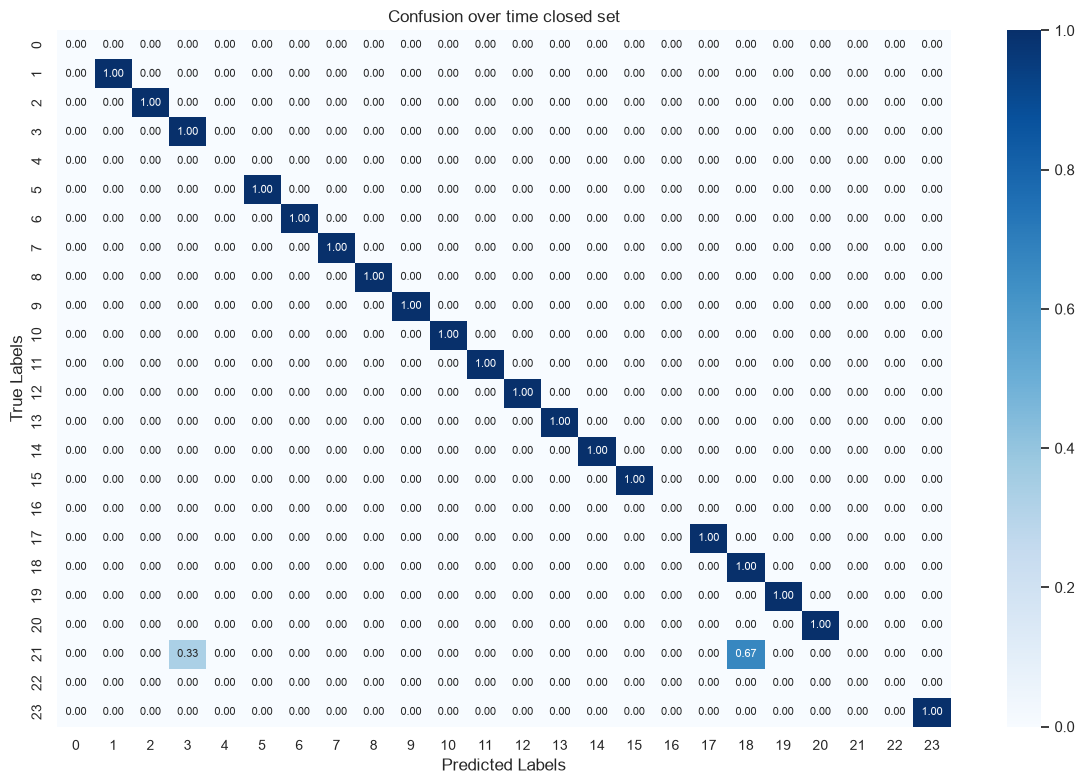

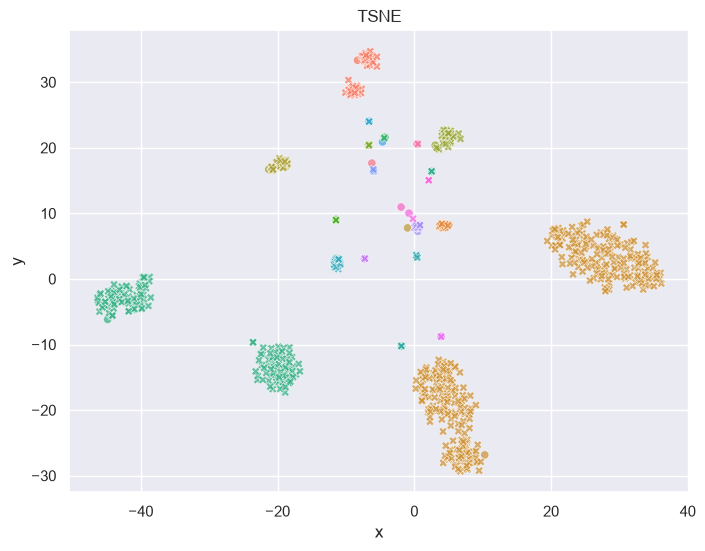

Rejection Accuracy: 0.9535
predicted 3730.0 queries out of 3912 correctly


c:\Users\julis\Desktop\WingPrint\Repos\WingPrint-Supervised\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: 100 NaN values found in confusion matrix have been replaced with zeros.
  warnings.warn(*args, **kwargs)


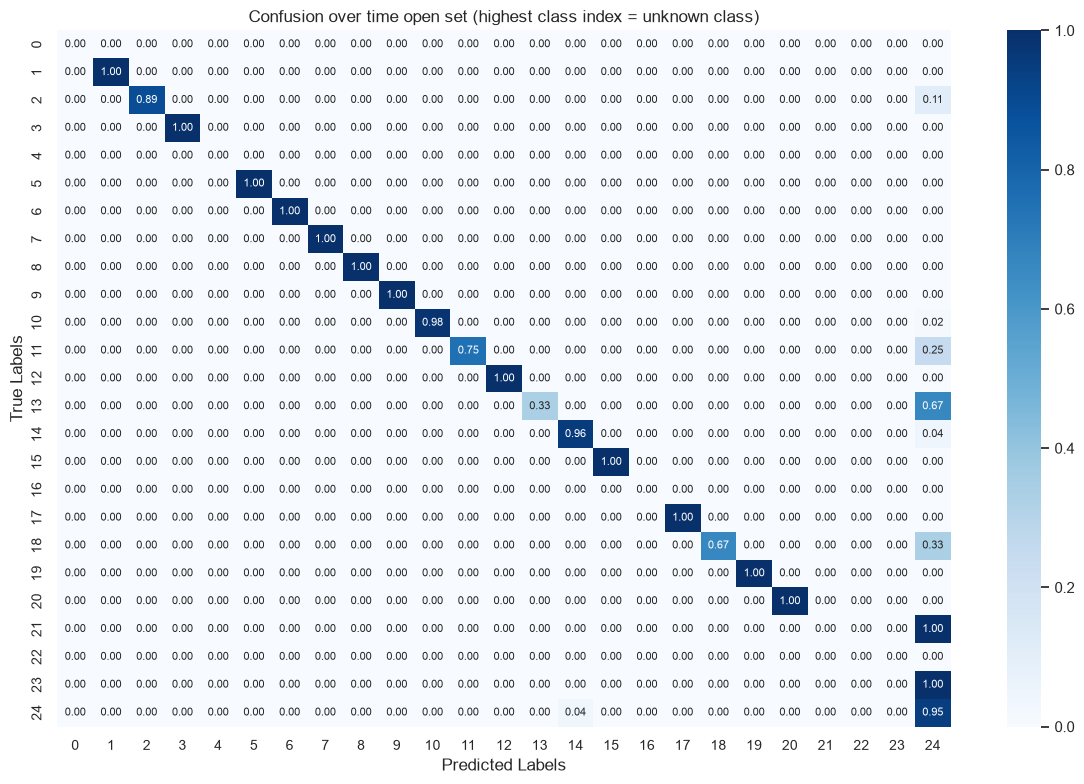

In [4]:
# create an unknown class with index num_classes
UNKNOWN_CLASS = num_classes
num_classes_with_unknowns = num_classes+1

predictions = []
closed_predictions = []
targets = []
closed_targets = []
relevances = []
features = []
labels = []

matchable_classes = [int(os.path.basename(path)) for path in glob.glob(os.path.join(TRAIN_DIR, '*'))]

closed_set_query_counter = 0
rejection_query_counter = 0

for point, individual_ID in zip(query_embeddings, query_names):
    dists = pairwise_distances(point.reshape(1, -1), gallery_embeddings, metric='cosine').squeeze()
    min_dist = dists.min()

    idx = dists.argmin()
    predicted_name = gallery_names[idx]

    # individuals are known if they have a match in A
    if individual_ID in matchable_classes:
        targets.append(train_data.class_map[individual_ID])
        closed_targets.append(train_data.class_map[individual_ID])
        closed_predictions.append(train_data.class_map[predicted_name])

        ranking = np.argsort(dists)
        relevance = (np.array(gallery_names)[ranking] == individual_ID).astype(int)
        relevances.append(relevance)

        features.append(point)
        labels.append(individual_ID)
    else:
        targets.append(UNKNOWN_CLASS)

    # this clause decides whether the model thinks that the current approach belongs to a known individual
    if min_dist <= REJECTION_THRESHOLD:
        predictions.append(train_data.class_map[predicted_name])
    else:
        predictions.append(UNKNOWN_CLASS)

accuracy = metrics.compute_accuracy(num_classes, closed_predictions, closed_targets)
f1_score = metrics.compute_f1_score(num_classes, closed_predictions, closed_targets)
mAP = metrics.compute_mean_average_precision(relevances)

rejection_predictions = [1 if p == UNKNOWN_CLASS else 0 for p in predictions]
rejection_targets = [1 if t == UNKNOWN_CLASS else 0 for t in targets]
rejection_accuracy = metrics.compute_accuracy(2, rejection_predictions, rejection_targets)

tsne_features = gallery_embeddings+features
tsne_labels = gallery_names+labels
categories = ['gallery']*len(gallery_embeddings)+['query']*len(features)

print(f"Closed Set Accuracy: {accuracy:.4f}")
print(f"Closed Set F1 Score: {accuracy:.4f}")
print(f"Closed Set Mean Average Precision: {mAP:.4f}")
print(f"predicted {accuracy*len(closed_targets)} queries out of {len(closed_targets)} correctly")
metrics.plot_confusion(num_classes, closed_predictions, closed_targets, "Confusion over time closed set", os.path.join(STATS_DIR, f"confusion_over_time_closed.pdf"))
metrics.plot_TSNE(num_classes, tsne_features, tsne_labels, categories, os.path.join(STATS_DIR, f"TSNE_over_time.pdf"))
print(f"Rejection Accuracy: {rejection_accuracy:.4f}")
print(f"predicted {rejection_accuracy*len(rejection_targets)} queries out of {len(rejection_targets)} correctly")
metrics.plot_confusion(num_classes_with_unknowns, predictions, targets, "Confusion over time open set (highest class index = unknown class)", os.path.join(STATS_DIR, f"confusion_over_time_open.pdf"))

## PAIR-X

Pairwise mAtching of Intermediate Representations for eXplainability: [https://github.com/pairx-explains/pairx](https://github.com/pairx-explains/pairx)

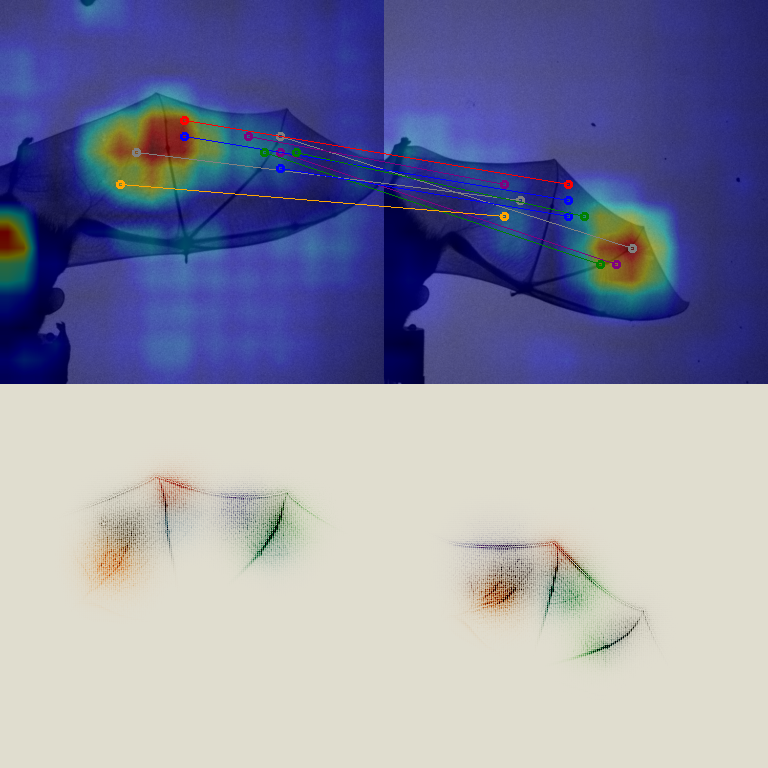

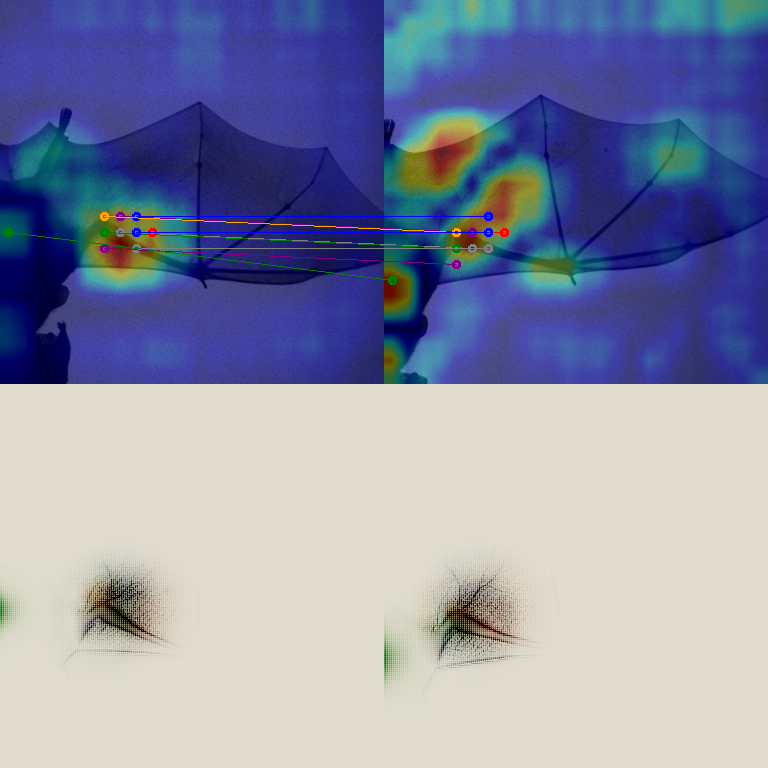

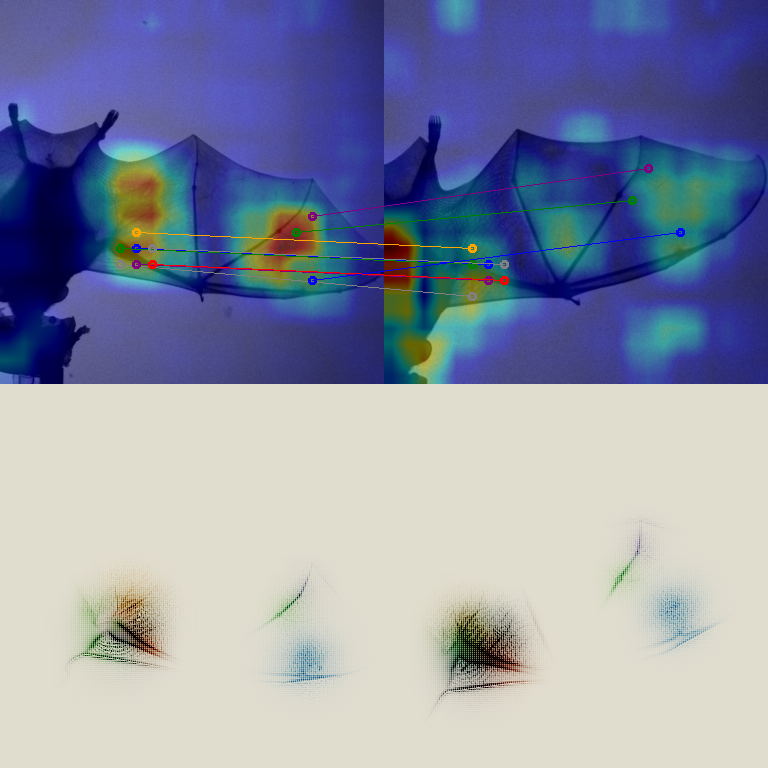

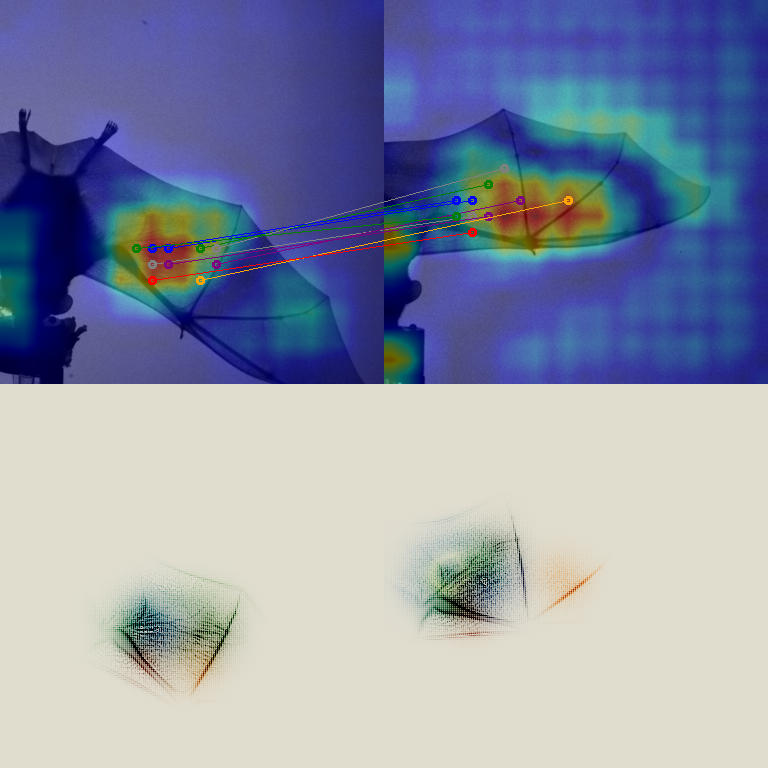

In [5]:
from pairx import core, xai_dataset

gallery_images = glob.glob(os.path.join(TRAIN_DIR, '**', '*.png'), recursive=True)

matchable_classes = [int(os.path.basename(path)) for path in glob.glob(os.path.join(TEST_DIR, '*'))]

model.returnEmbedding = True

for i in range(5):
    random_gallery_image = gallery_images[np.random.randint(len(gallery_images))]

    individual_ID = int(os.path.basename(os.path.dirname(os.path.dirname(random_gallery_image))))

    if individual_ID in matchable_classes:
        query_images = glob.glob(os.path.join(TEST_DIR, str(individual_ID), '**', '*.png'), recursive=True)
        random_query_image = query_images[np.random.randint(len(query_images))]

        img_size = (arcface_model.IMG_SIZE, arcface_model.IMG_SIZE)
        LAYER = "extractor.0.features.5"

        img_0, img_1, img_np_0, img_np_1 = xai_dataset.get_img_pair_from_paths(device, random_gallery_image, random_query_image, img_size, gallery_transform, query_transform)
        pairx_img = core.explain(device, img_0, img_1, img_np_0, img_np_1, model, [LAYER], k_lines=10, k_colors=10)[0]

        img = Image.fromarray(pairx_img)
        display(img)

model.returnEmbedding = False

## Evaluate Open-World prediction performance
Finally, we let the model predict how many individuals are in the unknown data and how their approaches are clustered.<br>
We start with an empty gallery and always calculate the centroid of all approaches belonging to an identity.

In [6]:
accuracies = []

# run 100 shuffled trials and average at the end because the order of the samples could have a significant impact on the results
for _ in tqdm(range(100)):
    unknown_points = [(f, n) for f, n, p in zip(query_embeddings, query_names, predictions) if p == UNKNOWN_CLASS]
    random.shuffle(unknown_points)

    gallery_embeddings = []
    gallery_centroids = []
    gallery_names = []
    open_world_predictions = []
    targets = []

    # unknown individuals
    for point, test_name in unknown_points:
        test_name = str(test_name)

        if len(gallery_embeddings) > 0:
            dists = pairwise_distances(point.reshape(1, -1), gallery_centroids, metric='cosine').squeeze()
            min_dist = dists.min()

            if min_dist <= REJECTION_THRESHOLD:
                idx = dists.argmin()
                predicted_name = gallery_names[idx]

                open_world_predictions.append(predicted_name)

                gallery_embeddings[idx].append(point)
                gallery_centroids[idx] = np.mean(gallery_embeddings[idx], axis=0)
            else:
                # create new individual in gallery
                gallery_embeddings.append([point])
                gallery_centroids.append(point)

                if test_name not in gallery_names:
                    # insert under original name
                    gallery_names.append(test_name)
                    open_world_predictions.append(test_name)
                else:
                    # modify name to indicate duplicate ID
                    c = 1
                    counted_name = f"{test_name}_{c}"

                    while counted_name in gallery_names:
                        c += 1
                        counted_name = f"{test_name}_{c}"
                
                    gallery_names.append(counted_name)
                    open_world_predictions.append(counted_name)
        else:
            gallery_embeddings.append([point])
            gallery_centroids.append(point)
            gallery_names.append(test_name)
            open_world_predictions.append(test_name)

        targets.append(test_name)

    assert(len(open_world_predictions) == len(targets))
    
    # match the predictions and the actual clusters
    predicted_clusters = defaultdict(list)
    true_clusters = defaultdict(list)

    for i, (pred, target) in enumerate(zip(open_world_predictions, targets)):
        # i is the approach index
        predicted_clusters[pred].append(i)
        true_clusters[target].append(i)
    
    # match the predicted clusters to the actual clusters based on the number of shared elements to evaluate prediction performance later.
    
    set_product = [] # this product is like a cartesian product of the sets but without regard to the order of the elements. So (a, b) = (b, a).

    for prediction, indices_1 in predicted_clusters.items():
        for target, indices_2 in true_clusters.items():
            shared_samples = list(set(indices_1).intersection(indices_2))

            if len(shared_samples) > 0:
                set_product.append((shared_samples, prediction, target))

    # the combinations are sorted based on the relative amount of shared elements
    set_product = sorted(set_product, key=lambda product: len(product[0])/(len(predicted_clusters[product[1]])+len(true_clusters[product[2]])), reverse=True)

    mapped_reference = {}
    num_shared = 0

    # assign predicted and actual clusters with the most shared elements to each other in a greedy manner
    for shared_elements, prediction, target in set_product:
        if prediction not in mapped_reference and target not in mapped_reference.values():
            mapped_reference[prediction] = target
            num_shared += len(shared_elements)

    accuracies.append(num_shared/len(targets))

print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"predicted {np.mean(accuracies)*len(targets)} queries out of {len(targets)} correctly (on average)")

100%|██████████| 100/100 [02:38<00:00,  1.59s/it]

Accuracy: 0.8875 ± 0.0203
predicted 2671.42 queries out of 3010 correctly (on average)
